In [7]:
import xarray as xr
import matplotlib.pyplot as plt

In [57]:
mod = "CM4"

ds = xr.open_dataset(
    f"/work/Katherine.Turner/stormtrack_variability/data/{mod}_cmip_monthly_storms.nc",
    use_cftime=True,
)

storms_seasonal = ds.center_counts.resample(time="QS-DEC").sum()

idx_jja = storms_seasonal.time.dt.month == 6
idx_djf = storms_seasonal.time.dt.month == 12

storms_djf = (
    storms_seasonal[idx_djf][1:-1] - storms_seasonal[idx_djf][1:-1].mean()
) / storms_seasonal[idx_djf][1:-1].std()
storms_jja = (
    storms_seasonal[idx_jja] - storms_seasonal[idx_jja].mean()
) / storms_seasonal[idx_jja].std()

STV = {}
STV["DJF"] = storms_djf
STV["JJA"] = storms_jja

low_storms = {}
high_storms = {}

low_storms["DJF"] = storms_djf.sortby(storms_djf).time[:50]
high_storms["DJF"] = storms_djf.sortby(storms_djf).time[-50:]

low_storms["JJA"] = storms_jja.sortby(storms_jja).time[:50]
high_storms["JJA"] = storms_jja.sortby(storms_jja).time[-50:]

In [58]:
ds_mld = xr.open_mfdataset(f"/work/Katherine.Turner/tempest-extremes/{mod}_cmip/data/ocean_monthly*omldamax.nc", use_cftime=True)

(-80.0, -60.0)

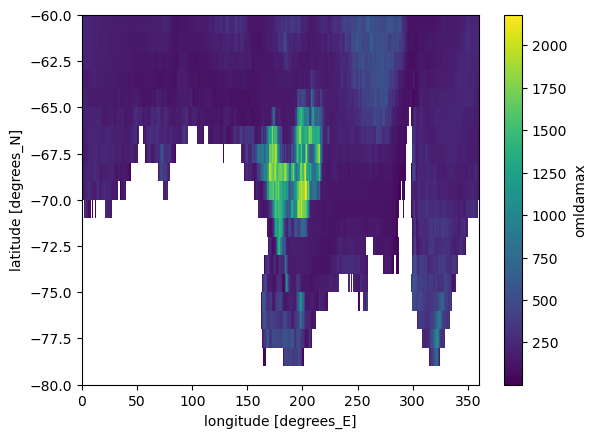

In [59]:
(ds_mld.omldamax.resample(time="QS-DEC").max()[2::4]).max(dim='time').plot()
plt.ylim([-80, -60])

In [60]:
mld_ross = ds_mld.omldamax.resample(time="QS-DEC").max().sel({"lat":-69, "lon":170}, method="nearest")

(1.0, 3.0)

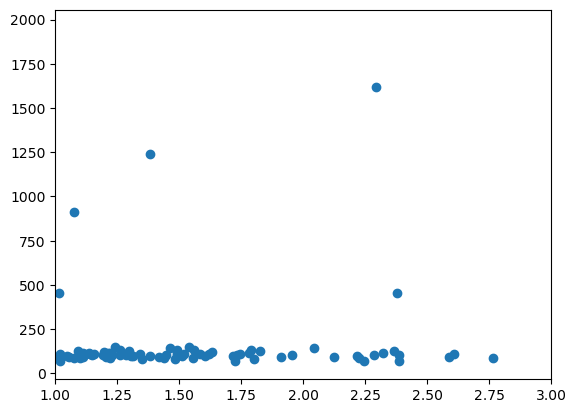

In [61]:
plt.scatter(STV['JJA'], mld_ross[2::4])
plt.xlim([1, 3])

In [62]:
idx_stv = STV['JJA'].time.dt.year.isin(high_storms['JJA'].dt.year)
idx_mld = mld_ross[2::4].time.dt.year.isin(high_storms['JJA'].dt.year)
idx_mld_sp = (mld_ross[2::4] > 250).compute()

In [63]:
mld_ross[2::4][idx_mld_sp].time.dt.year

<xarray.DataArray 'year' (time: 16)>
array([235, 236, 330, 333, 334, 339, 437, 444, 536, 541, 542, 547, 548, 549,
       550, 552])
Coordinates:
    lat      float64 -68.5
    lon      float64 170.5
  * time     (time) object 0235-06-01 00:00:00 ... 0552-06-01 00:00:00

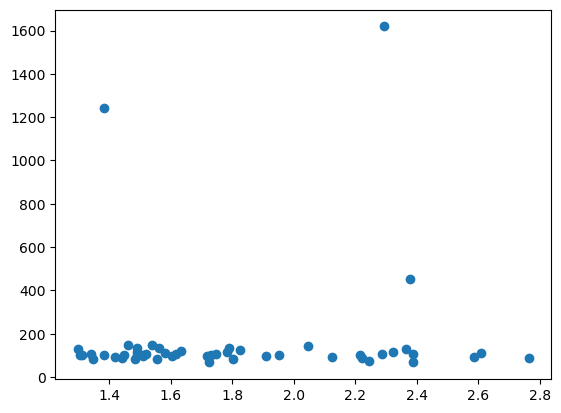

In [64]:
plt.scatter(STV['JJA'][idx_stv], mld_ross[2::4][idx_mld])

In [44]:
STV['JJA'].time[idx_stv].dt.year

<xarray.DataArray 'year' (time: 50)>
array([  2,  28,  34,  51,  52,  53,  74,  75,  94,  97,  98,  99, 111,
       114, 116, 134, 137, 141, 144, 148, 157, 158, 175, 186, 197, 208,
       213, 216, 240, 252, 263, 275, 277, 286, 317, 337, 339, 382, 384,
       390, 394, 408, 409, 450, 457, 459, 467, 478, 484, 486])
Coordinates:
  * time     (time) object 0002-06-01 00:00:00 ... 0486-06-01 00:00:00

In [49]:
mld_ross[2::4].time[idx_mld].dt.year

<xarray.DataArray 'year' (time: 50)>
array([  2,  28,  34,  51,  52,  53,  74,  75,  94,  97,  98,  99, 111,
       114, 116, 134, 137, 141, 144, 148, 157, 158, 175, 186, 197, 208,
       213, 216, 240, 252, 263, 275, 277, 286, 317, 337, 339, 382, 384,
       390, 394, 408, 409, 450, 457, 459, 467, 478, 484, 486])
Coordinates:
    lat      float64 -68.5
    lon      float64 170.5
  * time     (time) object 0002-06-01 00:00:00 ... 0486-06-01 00:00:00

In [65]:
mld_ross[2::4].time[idx_mld_sp & idx_mld].dt.year

<xarray.DataArray 'year' (time: 3)>
array([334, 437, 548])
Coordinates:
    lat      float64 -68.5
    lon      float64 170.5
  * time     (time) object 0334-06-01 00:00:00 ... 0548-06-01 00:00:00